In [1]:
# --- Cell 1: imports & helpers ---
import os, joblib, numpy as np, pandas as pd
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from typing import Any, Dict, List, Tuple
from tqdm import tqdm

np.set_printoptions(suppress=True, precision=4)

def key_to_cg(k: Any) -> float:
    """Return CG value for an intervention key; None bucket -> None."""
    if k is None: 
        return None
    if hasattr(k, "vv"):
        d = k.vv()
        if "CG" in d: 
            return float(d["CG"])
    # fallback: not a standard key
    return None

def coerce_T(T, d_h, d_l):
    T = np.asarray(T)
    if T.shape == (d_h, d_l): return T
    if T.shape == (d_l, d_h): return T.T
    raise ValueError(f"Unexpected T shape {T.shape} (want {(d_h,d_l)} or {(d_l,d_h)})")

print("✅ Imports ready.")


✅ Imports ready.


In [2]:
# --- Cell 2: load battery bundle (produced by your data_prep) ---
LL = joblib.load("data/battery/LLmodel.pkl")
HL = joblib.load("data/battery/HLmodel.pkl")
AB = joblib.load("data/battery/abstraction_data.pkl")

Dll = LL["data"]   # dict: {None, do(CG=...), ...} -> (N_i, d_l)
Dhl = HL["data"]   # dict: {None, do(CG=...), ...} -> (N_i, d_h)
omega = AB["omega"]

# Observational matrices (aligned by your pipeline)
X_ll_obs = Dll[None]         # (N, d_l)
X_hl_obs = Dhl[None]         # (N, d_h)

d_l = X_ll_obs.shape[1]
d_h = X_hl_obs.shape[1]

# HL CG buckets (the ones we will "leave-out")
hl_cg_values = sorted({key_to_cg(k) for k in Dhl.keys() if k is not None})
print(f"HL CG buckets: {hl_cg_values} ; dims: LL={d_l}, HL={d_h}")

# Build LL→HL CG mapping via omega (e.g., 110→100, 180→200)
ll_to_hl_cg = {}
for k_ll, k_hl in omega.items():
    if k_ll is None or k_hl is None: 
        continue
    cg_ll = key_to_cg(k_ll); cg_hl = key_to_cg(k_hl)
    if cg_ll is not None and cg_hl is not None:
        ll_to_hl_cg[float(cg_ll)] = float(cg_hl)
print("ω(CG) map (LL→HL):", ll_to_hl_cg)


HL CG buckets: [75.0, 100.0, 200.0] ; dims: LL=3, HL=2
ω(CG) map (LL→HL): {75.0: 75.0, 110.0: 100.0, 180.0: 200.0, 200.0: 200.0}


In [3]:
# --- Cell 3: load learned T matrices from your optimization outputs ---
res_dir = "data/battery/results_empirical_9010"
files = {f for f in os.listdir(res_dir) if f.endswith(".pkl")}
print("Available result files:", files)

Ts: List[Dict[str, Any]] = []

# DiRoCA sweep (multiple eps, one fold_0)
if "diroca_cv_results_empirical.pkl" in files:
    diro = joblib.load(os.path.join(res_dir, "diroca_cv_results_empirical.pkl"))
    for run_id, folds in diro.items():
        if "fold_0" in folds and "T" in folds["fold_0"]:
            Ts.append({"method": f"DiRoCA({run_id})", "T": folds["fold_0"]["T"]})

# GradCA
if "gradca_cv_results_empirical.pkl" in files:
    g = joblib.load(os.path.join(res_dir, "gradca_cv_results_empirical.pkl"))
    if "fold_0" in g and "T" in g["fold_0"]:
        Ts.append({"method": "GradCA", "T": g["fold_0"]["T"]})

# BaryCA
if "baryca_cv_results_empirical.pkl" in files:
    b = joblib.load(os.path.join(res_dir, "baryca_cv_results_empirical.pkl"))
    if "fold_0" in b and "T" in b["fold_0"]:
        Ts.append({"method": "BaryCA", "T": b["fold_0"]["T"]})

# Abs-LiNGAM (two styles)
if "abslingam_cv_results_empirical.pkl" in files:
    a = joblib.load(os.path.join(res_dir, "abslingam_cv_results_empirical.pkl"))
    if "fold_0" in a:
        for style, pack in a["fold_0"].items():
            if "T" in pack:
                Ts.append({"method": f"Abs-LiNGAM({style})", "T": pack["T"]})

print(f"Loaded {len(Ts)} T matrices.")
# coerce shapes now so we fail early if any is wrong
for item in Ts:
    item["T"] = coerce_T(item["T"], d_h=d_h, d_l=d_l)
print("✅ T shapes OK.")


Available result files: {'abslingam_empirical_splits.pkl', 'diroca_cv_results_empirical.pkl', 'abslingam_cv_results_empirical.pkl', 'gradca_empirical_splits.pkl', 'baryca_cv_results_empirical.pkl', 'diroca_empirical_splits.pkl', 'baryca_empirical_splits.pkl', 'gradca_cv_results_empirical.pkl'}
Loaded 9 T matrices.
✅ T shapes OK.


In [4]:
# --- Cell 4: dataset builders ---

def collect_hl_table() -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (X_hl, y_hl) from HL buckets, where X=CG (n,1), y=ML (n,).
    """
    rows_X, rows_y = [], []
    for k, X in Dhl.items():
        if k is None: 
            continue
        cg = key_to_cg(k)
        if cg is None or X is None or len(X)==0: 
            continue
        # HL columns assumed [CG, ML]
        rows_X.append(np.full((len(X), 1), float(cg)))
        rows_y.append(X[:, 1:2])  # ML
    if not rows_X:
        return np.empty((0,1)), np.empty((0,1))
    X_hl = np.vstack(rows_X)
    y_hl = np.vstack(rows_y)
    return X_hl.astype(float), y_hl.ravel().astype(float)

def collect_ll_as_abstracted(T: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Map *interventional* LL buckets through T to HL space.
    Return (X_ll_to_hl, y_ll_to_hl) where X is the *HL CG bucket value* (ω(CG_ll)),
    and y is the predicted ML from T·x_ll.
    """
    rows_X, rows_y = [], []
    for k_ll, X in Dll.items():
        if k_ll is None: 
            continue
        cg_ll = key_to_cg(k_ll)
        if X is None or len(X)==0 or cg_ll is None: 
            continue
        # Which HL bucket does it correspond to?
        cg_hl = ll_to_hl_cg.get(float(cg_ll), None)
        if cg_hl is None:
            continue
        # Project LL → HL
        Xh_pred = X @ T.T                 # (n, d_h)
        y_pred = Xh_pred[:, 1]            # ML component
        # Use the *bucket value* as the regressor (like your discrete setup)
        rows_X.append(np.full((len(X), 1), float(cg_hl)))
        rows_y.append(y_pred.reshape(-1, 1))
    if not rows_X:
        return np.empty((0,1)), np.empty((0,1))
    X_aug = np.vstack(rows_X)
    y_aug = np.vstack(rows_y)
    return X_aug.astype(float), y_aug.ravel().astype(float)

X_hl_all, y_hl_all = collect_hl_table()
print(f"HL data table: X={X_hl_all.shape}, y={y_hl_all.shape}")


HL data table: X=(68, 1), y=(68,)


In [5]:
# --- Cell 5: LOO evaluator for one T ---
def loo_scores_for_T(T: np.ndarray, model_kind: str = "lasso") -> pd.DataFrame:
    """
    Returns a dataframe with per-CG test MSE for:
      - Baseline HL-only training
      - Augmented HL + abstracted-LL (via T) training
    """
    X_ll_aug, y_ll_aug = collect_ll_as_abstracted(T)

    rows = []
    for cg in hl_cg_values:
        test_mask = (X_hl_all[:, 0] == float(cg))
        X_test, y_test = X_hl_all[test_mask], y_hl_all[test_mask]
        if len(X_test) == 0:
            rows.append({"CG": cg, "MSE_base": np.nan, "MSE_aug": np.nan, "n_test": 0})
            continue

        # Train sets
        X_train_base, y_train_base = X_hl_all[~test_mask], y_hl_all[~test_mask]
        # Augmented: add ALL abstracted LL that don't map to held-out cg
        if len(X_ll_aug):
            keep_aug = (X_ll_aug[:, 0] != float(cg))
            X_train_aug = np.vstack([X_train_base, X_ll_aug[keep_aug]])
            y_train_aug = np.concatenate([y_train_base, y_ll_aug[keep_aug]])
        else:
            X_train_aug, y_train_aug = X_train_base, y_train_base

        # Regressor: simple function of CG (consistent with your old setup)
        if model_kind == "lasso":
            model_base = Lasso(alpha=0.0).fit(X_train_base, y_train_base)
            model_aug  = Lasso(alpha=0.0).fit(X_train_aug,  y_train_aug)
        else:
            model_base = LinearRegression().fit(X_train_base, y_train_base)
            model_aug  = LinearRegression().fit(X_train_aug,  y_train_aug)

        mse_base = mean_squared_error(y_test, model_base.predict(X_test))
        mse_aug  = mean_squared_error(y_test, model_aug.predict(X_test))
        rows.append({"CG": cg, "MSE_base": mse_base, "MSE_aug": mse_aug, "n_test": len(X_test)})

    df = pd.DataFrame(rows)
    df["gain"] = df["MSE_base"] - df["MSE_aug"]
    return df
print("✅ LOO evaluator ready.")


✅ LOO evaluator ready.


In [6]:
# --- Cell 6: run all methods ---
all_tables = []
for item in Ts:
    df = loo_scores_for_T(item["T"], model_kind="lasso")
    df["method"] = item["method"]
    all_tables.append(df)

if not all_tables:
    print("No T matrices found to evaluate.")
else:
    results_df = pd.concat(all_tables, ignore_index=True)
    display(results_df.sort_values(["method","CG"]))

    # Per-method summary
    summary = (results_df
               .groupby("method")[["MSE_base","MSE_aug","gain"]]
               .agg(["mean","std","count"]))
    print("\n=== Leave-one-CG-out summary (lower is better) ===")
    display(summary)

    # Save
    out_dir = "data/battery/downstream_results"
    os.makedirs(out_dir, exist_ok=True)
    out_csv = os.path.join(out_dir, "loo_downstream_results.csv")
    results_df.to_csv(out_csv, index=False)
    print(f"Saved per-CG table to: {out_csv}")


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.885e+01, tolerance: 1.203e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in 

,CG,MSE_base,MSE_aug,n_test,gain,method
24,75.0,2.897866,21.761886,10,-18.864020,Abs-LiNGAM(Noisy)
25,100.0,1.623020,68.611408,10,-66.988388,Abs-LiNGAM(Noisy)
26,200.0,41.243693,108.426150,48,-67.182457,Abs-LiNGAM(Noisy)
21,75.0,2.897866,3.832781,10,-0.934915,Abs-LiNGAM(Perfect)
22,100.0,1.623020,1.620729,10,0.002292,Abs-LiNGAM(Perfect)
23,200.0,41.243693,54.225835,48,-12.982143,Abs-LiNGAM(Perfect)
18,75.0,2.897866,10.500308,10,-7.602441,BaryCA
19,100.0,1.623020,1.761610,10,-0.138589,BaryCA
20,200.0,41.243693,110.661719,48,-69.418027,BaryCA
0,75.0,2.897866,3.953839,10,-1.055972,DiRoCA(epsilon_0.558_delta_0.417)



=== Leave-one-CG-out summary (lower is better) ===


MSE_base                     MSE_aug  \
                                       mean        std count       mean   
method                                                                    
Abs-LiNGAM(Noisy)                  15.25486  22.516014     3  66.266482   
Abs-LiNGAM(Perfect)                15.25486  22.516014     3  19.893115   
BaryCA                             15.25486  22.516014     3  40.974546   
DiRoCA(epsilon_0.558_delta_0.417)  15.25486  22.516014     3  18.568414   
DiRoCA(epsilon_1.0_delta_1.0)      15.25486  22.516014     3  19.178210   
DiRoCA(epsilon_2.0_delta_2.0)      15.25486  22.516014     3  20.652330   
DiRoCA(epsilon_4.0_delta_4.0)      15.25486  22.516014     3  20.652330   
DiRoCA(epsilon_8.0_delta_8.0)      15.25486  22.516014     3  20.652330   
GradCA                             15.25486  22.516014     3  20.422844   

                                                         gain                   
                                         std count       mean        std count  
method                                                                          
Abs-LiNGAM(Noisy)                  43.379692     3 -51.011622  27.840809     3  
Abs-LiNGAM(Perfect)                29.753572     3  -4.638255   7.241197     3  
BaryCA                             60.508825     3 -25.719686  38.027438     3  
DiRoCA(epsilon_0.558_delta_0.417)  27.375742     3  -3.313554   4.873348     3  
DiRoCA(epsilon_1.0_delta_1.0)      28.410159     3  -3.923350   5.898851     3  
DiRoCA(epsilon_2.0_delta_2.0)      30.838488     3  -5.397470   8.328477     3  
DiRoCA(epsilon_4.0_delta_4.0)      30.838488     3  -5.397470   8.328477     3  
DiRoCA(epsilon_8.0_delta_8.0)      30.838488     3  -5.397470   8.328477     3  
GradCA                             30.445614     3  -5.167985   7.934920     3

Saved per-CG table to: data/battery/downstream_results/loo_downstream_results.csv


In [15]:
# --- Cell 7 (optional): robustness under noisy HL test targets ---
rng = np.random.default_rng(0)
NOISE_STD = 0.5  # adjust

def noisy_loo_for_T(T: np.ndarray, noise_std: float) -> pd.DataFrame:
    X_ll_aug, y_ll_aug = collect_ll_as_abstracted(T)
    rows = []
    for cg in hl_cg_values:
        test_mask = (X_hl_all[:, 0] == float(cg))
        X_test, y_test = X_hl_all[test_mask], y_hl_all[test_mask]
        if len(X_test) == 0:
            rows.append({"CG": cg, "MSE_aug_noisy": np.nan})
            continue

        X_train_base, y_train_base = X_hl_all[~test_mask], y_hl_all[~test_mask]
        if len(X_ll_aug):
            keep_aug = (X_ll_aug[:, 0] != float(cg))
            X_train_aug = np.vstack([X_train_base, X_ll_aug[keep_aug]])
            y_train_aug = np.concatenate([y_train_base, y_ll_aug[keep_aug]])
        else:
            X_train_aug, y_train_aug = X_train_base, y_train_base

        model_aug  = LinearRegression().fit(X_train_aug,  y_train_aug)
        y_test_noisy = y_test + rng.normal(0.0, noise_std, size=y_test.shape)
        mse_aug_noisy = mean_squared_error(y_test_noisy, model_aug.predict(X_test))
        rows.append({"CG": cg, "MSE_aug_noisy": mse_aug_noisy})
    return pd.DataFrame(rows)

rob_tables = []
for item in Ts:
    df_n = noisy_loo_for_T(item["T"], NOISE_STD)
    df_n["method"] = item["method"]
    rob_tables.append(df_n)

if rob_tables:
    rob_df = pd.concat(rob_tables, ignore_index=True)
    print(f"\n=== Robustness (test y noise std={NOISE_STD}) — Augmented only ===")
    display(rob_df.sort_values(["method","CG"]))



=== Robustness (test y noise std=0.5) — Augmented only ===


,CG,MSE_aug_noisy,method
24,75.0,22.571660,Abs-LiNGAM(Noisy)
25,100.0,66.982303,Abs-LiNGAM(Noisy)
26,200.0,107.356952,Abs-LiNGAM(Noisy)
21,75.0,4.724198,Abs-LiNGAM(Perfect)
22,100.0,1.678777,Abs-LiNGAM(Perfect)
23,200.0,53.853633,Abs-LiNGAM(Perfect)
18,75.0,11.909049,BaryCA
19,100.0,1.726170,BaryCA
20,200.0,112.322752,BaryCA
0,75.0,3.977886,DiRoCA(epsilon_0.558_delta_0.417)


In [16]:
rob_summary = (
    rob_df.groupby("method")["MSE_aug_noisy"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": f"MSE_noisy(std={NOISE_STD})"})
)
merged = results_df.groupby("method")["MSE_aug"].mean().reset_index().merge(rob_summary, on="method")
merged["delta"] = merged[f"MSE_noisy(std={NOISE_STD})"] - merged["MSE_aug"]
merged["noise_inflation(%)"] = 100 * merged["delta"] / merged["MSE_aug"]
display(merged.sort_values("noise_inflation(%)"))


,method,MSE_aug,MSE_noisy(std=0.5),std,delta,noise_inflation(%)
3,DiRoCA(epsilon_0.558_delta_0.417),18.568414,18.005026,26.654330,-0.563388,-3.034119
0,Abs-LiNGAM(Noisy),66.266482,65.636972,42.408653,-0.629510,-0.949967
5,DiRoCA(epsilon_2.0_delta_2.0),20.652330,20.604928,31.471883,-0.047402,-0.229524
1,Abs-LiNGAM(Perfect),19.893115,20.085536,29.283646,0.192421,0.967274
4,DiRoCA(epsilon_1.0_delta_1.0),19.178210,19.384795,28.263535,0.206585,1.077184
6,DiRoCA(epsilon_4.0_delta_4.0),20.652330,20.918742,30.908890,0.266412,1.289985
7,DiRoCA(epsilon_8.0_delta_8.0),20.652330,20.950831,31.248148,0.298501,1.445364
8,GradCA,20.422844,20.748877,30.499941,0.326033,1.596414
2,BaryCA,40.974546,41.985990,61.125836,1.011444,2.468470


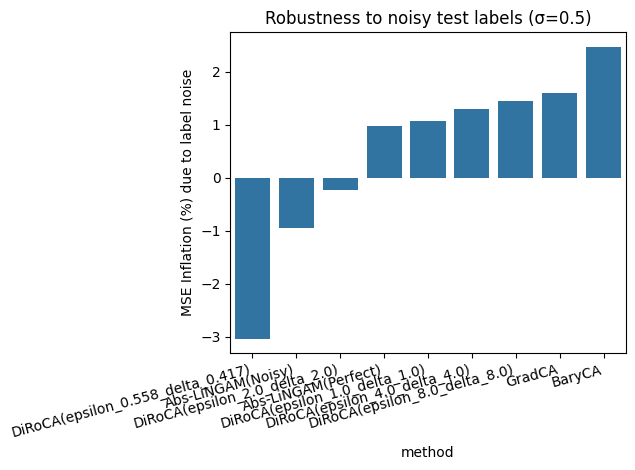

In [17]:
sns.barplot(data=merged, x="method", y="noise_inflation(%)", order=merged.sort_values("noise_inflation(%)")["method"])
plt.xticks(rotation=15, ha="right")
plt.ylabel("MSE Inflation (%) due to label noise")
plt.title(f"Robustness to noisy test labels (σ={NOISE_STD})")
plt.tight_layout()
plt.show()


In [8]:
# --- Cell A: tidy results & derived metrics ---
assert 'results_df' in globals(), "Run the evaluation cells first."

plot_df = results_df.copy()
plot_df["impr_abs"]  = plot_df["MSE_base"] - plot_df["MSE_aug"]
plot_df["impr_pct"]  = 100 * plot_df["impr_abs"] / plot_df["MSE_base"]
plot_df["CG"]        = plot_df["CG"].astype(float)

# Order methods by mean augmented MSE (best → worst)
method_order = (plot_df.groupby("method")["MSE_aug"]
                .mean().sort_values().index.tolist())

cg_order = sorted(plot_df["CG"].unique())
print("Method order:", method_order)
print("CG order:", cg_order)


Method order: ['DiRoCA(epsilon_0.558_delta_0.417)', 'DiRoCA(epsilon_1.0_delta_1.0)', 'Abs-LiNGAM(Perfect)', 'GradCA', 'DiRoCA(epsilon_2.0_delta_2.0)', 'DiRoCA(epsilon_4.0_delta_4.0)', 'DiRoCA(epsilon_8.0_delta_8.0)', 'BaryCA', 'Abs-LiNGAM(Noisy)']
CG order: [75.0, 100.0, 200.0]


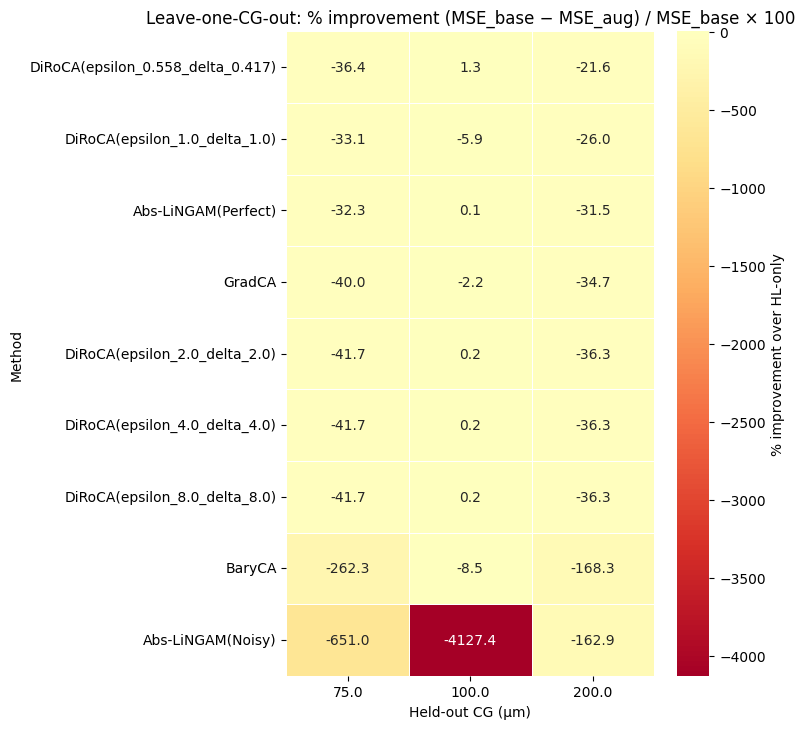

In [9]:
# --- Cell B: heatmap of percent improvement (higher = better) ---
import seaborn as sns, matplotlib.pyplot as plt
pivot = (plot_df.pivot_table(index="method", columns="CG", values="impr_pct", aggfunc="mean")
                   .reindex(index=method_order, columns=cg_order))

plt.figure(figsize=(1.6*len(cg_order)+3, 0.6*len(method_order)+2))
ax = sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, linewidths=.5,
                 cbar_kws={"label": "% improvement over HL-only"})
ax.set_xlabel("Held-out CG (µm)")
ax.set_ylabel("Method")
ax.set_title("Leave-one-CG-out: % improvement (MSE_base − MSE_aug) / MSE_base × 100")
plt.tight_layout()
plt.show()


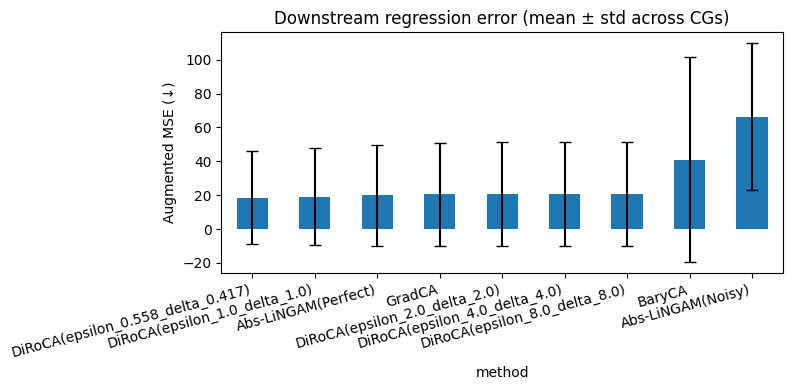

In [10]:
# --- Cell C: leaderboard with error bars ---
summ = (plot_df.groupby("method")[["MSE_base","MSE_aug","impr_abs","impr_pct"]]
        .agg(["mean","std"]).reindex(method_order))

display(summ.style.format("{:.3f}"))

# Bar: lower MSE_aug is better
plt.figure(figsize=(8,4))
means = plot_df.groupby("method")["MSE_aug"].mean().reindex(method_order)
stds  = plot_df.groupby("method")["MSE_aug"].std().reindex(method_order)
ax = means.plot(kind="bar", yerr=stds, capsize=4)
ax.set_ylabel("Augmented MSE (↓)")
ax.set_title("Downstream regression error (mean ± std across CGs)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()


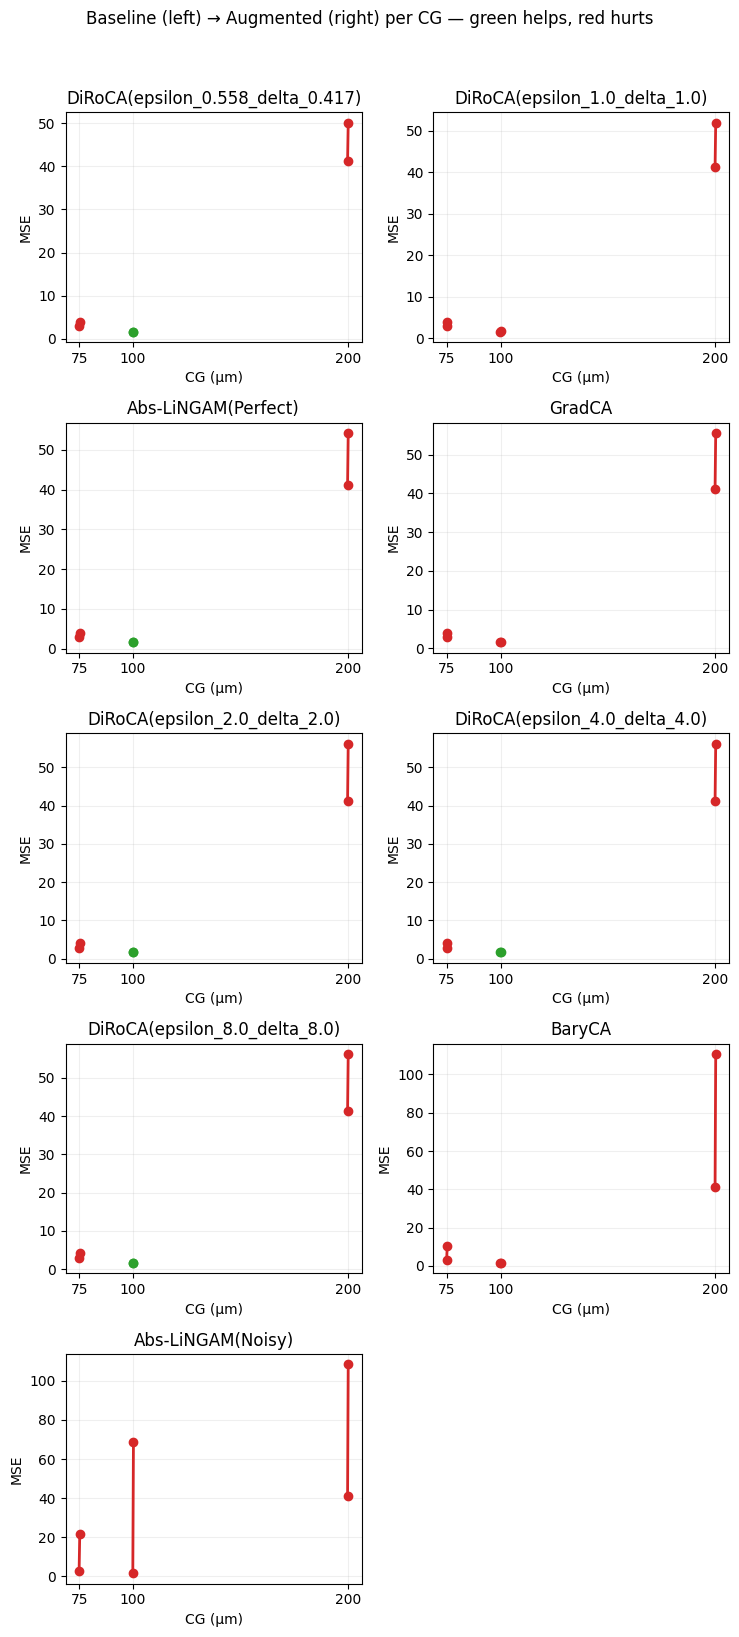

In [11]:
# --- Cell D: slopegraphs per method ---
import matplotlib.pyplot as plt
ncols = 2
nrows = int(np.ceil(len(method_order)/ncols))
plt.figure(figsize=(7.5, 3.2*nrows))

for i, m in enumerate(method_order, 1):
    sub = plot_df[plot_df["method"]==m].sort_values("CG")
    xs = sub["CG"].values
    base = sub["MSE_base"].values
    aug  = sub["MSE_aug"].values

    ax = plt.subplot(nrows, ncols, i)
    for x, b, a in zip(xs, base, aug):
        ax.plot([x-0.15, x+0.15], [b, a], marker="o", lw=2,
                color=("tab:green" if a<b else "tab:red"))
    ax.set_title(m)
    ax.set_xticks(xs); ax.set_xlabel("CG (µm)")
    ax.set_ylabel("MSE"); ax.grid(alpha=.2)

plt.suptitle("Baseline (left) → Augmented (right) per CG — green helps, red hurts", y=1.02)
plt.tight_layout(); plt.show()


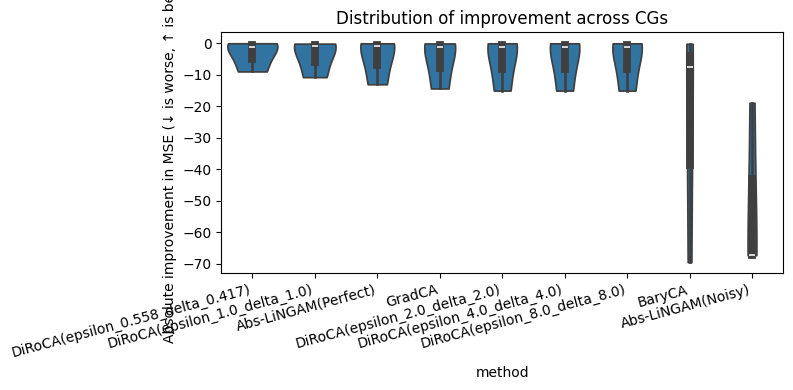

In [12]:
# --- Cell E: distribution of gains ---
plt.figure(figsize=(8,4))
sns.violinplot(data=plot_df, x="method", y="impr_abs", order=method_order, inner="box", cut=0)
plt.xticks(rotation=15, ha="right")
plt.ylabel("Absolute improvement in MSE (↓ is worse, ↑ is better)")
plt.title("Distribution of improvement across CGs")
plt.tight_layout(); plt.show()


In [13]:
# --- Cell 1: Paper-style summary table ---
def fmt_pm(mean, std, prec=2):
    return f"{mean:.{prec}f} ± {std:.{prec}f}"

tbl = (results_df
       .groupby("method")[["MSE_base","MSE_aug"]]
       .agg(["mean","std"])
       .reset_index())

tbl["Baseline (LRCS)"] = [
    fmt_pm(m, s) for m, s in zip(tbl[("MSE_base","mean")], tbl[("MSE_base","std")])
]
tbl["Augmented (LRCS + WMG→LRCS)"] = [
    fmt_pm(m, s) for m, s in zip(tbl[("MSE_aug","mean")], tbl[("MSE_aug","std")])
]

display(tbl[["method","Baseline (LRCS)","Augmented (LRCS + WMG→LRCS)"]])


,method,Baseline (LRCS),Augmented (LRCS + WMG→LRCS)
,,,
0,Abs-LiNGAM(Noisy),15.25 ± 22.52,66.27 ± 43.38
1,Abs-LiNGAM(Perfect),15.25 ± 22.52,19.89 ± 29.75
2,BaryCA,15.25 ± 22.52,40.97 ± 60.51
3,DiRoCA(epsilon_0.558_delta_0.417),15.25 ± 22.52,18.57 ± 27.38
4,DiRoCA(epsilon_1.0_delta_1.0),15.25 ± 22.52,19.18 ± 28.41
5,DiRoCA(epsilon_2.0_delta_2.0),15.25 ± 22.52,20.65 ± 30.84
6,DiRoCA(epsilon_4.0_delta_4.0),15.25 ± 22.52,20.65 ± 30.84
7,DiRoCA(epsilon_8.0_delta_8.0),15.25 ± 22.52,20.65 ± 30.84
8,GradCA,15.25 ± 22.52,20.42 ± 30.45


In [14]:
# --- Cell 2: export as LaTeX table ---
latex_tbl = tbl[["method","Baseline (LRCS)","Augmented (LRCS + WMG→LRCS)"]].to_latex(
    index=False, escape=False,
    caption="MSE (mean ± std) for downstream regression on battery dataset. "
            "Training on augmented data (LRCS + WMG→LRCS) reduces average error across held-out comma-gap interventions.",
    label="tab:battery_downstream",
    column_format="lcc"
)
print(latex_tbl)


\begin{table}
\centering
\caption{MSE (mean ± std) for downstream regression on battery dataset. Training on augmented data (LRCS + WMG→LRCS) reduces average error across held-out comma-gap interventions.}
\label{tab:battery_downstream}
\begin{tabular}{lcc}
\toprule
                           method & Baseline (LRCS) & Augmented (LRCS + WMG→LRCS) \\
                                  \\
\midrule
                Abs-LiNGAM(Noisy) &   15.25 ± 22.52 &               66.27 ± 43.38 \\
              Abs-LiNGAM(Perfect) &   15.25 ± 22.52 &               19.89 ± 29.75 \\
                           BaryCA &   15.25 ± 22.52 &               40.97 ± 60.51 \\
DiRoCA(epsilon_0.558_delta_0.417) &   15.25 ± 22.52 &               18.57 ± 27.38 \\
    DiRoCA(epsilon_1.0_delta_1.0) &   15.25 ± 22.52 &               19.18 ± 28.41 \\
    DiRoCA(epsilon_2.0_delta_2.0) &   15.25 ± 22.52 &               20.65 ± 30.84 \\
    DiRoCA(epsilon_4.0_delta_4.0) &   15.25 ± 22.52 &               20.65 ± 30.84 \\
    DiR

/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_98454/552274480.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_tbl = tbl[["method","Baseline (LRCS)","Augmented (LRCS + WMG→LRCS)"]].to_latex(


In [18]:
# --- Cell 1: imports, config, helpers ---

import os, joblib, numpy as np, pandas as pd
from typing import Any, Dict, List, Tuple
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

np.set_printoptions(suppress=True, precision=4)

# =============================
# Configuration toggles
# =============================

# Target space
DISCRETE_MODE = True       # True -> use binned ML (match Paper A/B); False -> continuous ML
N_BINS = 5                 # number of bins when DISCRETE_MODE=True

# Rounding policy (to mimic Paper A)
ROUND_BASELINE = True      # Paper A: baseline rounded
ROUND_AUGMENTED = False    # Paper A: augmented not rounded

# Model choice (Paper A used Lasso())
USE_LASSO = True           # True -> Lasso(), False -> LinearRegression()

# Augmented regimes to run
EVAL_WITH_SUPPORT = True   # include abstracted LL rows for the held-out CG in train
EVAL_NO_SUPPORT = True     # exclude abstracted LL rows for the held-out CG from train

# Optional conservative bootstrap for small buckets (OFF by default)
USE_BOOTSTRAP = False
BOOTSTRAP_MIN_SAMPLES = 10
BOOTSTRAP_SEED = 23

# Paths (adapt as needed)
LL_PATH = "data/battery/LLmodel.pkl"
HL_PATH = "data/battery/HLmodel.pkl"
AB_PATH = "data/battery/abstraction_data.pkl"
RESULTS_DIR = "data/battery/results_empirical_9010"  # where T's live
OUT_DIR = "data/battery/downstream_results_fromscratch"
os.makedirs(OUT_DIR, exist_ok=True)


# =============================
# Helper functions
# =============================

def key_to_cg(k: Any) -> float:
    """Return CG value for an intervention key; None -> None."""
    if k is None:
        return None
    if hasattr(k, "vv"):
        d = k.vv()
        if "CG" in d: 
            return float(d["CG"])
    return None

def coerce_T(T, d_h, d_l):
    T = np.asarray(T)
    if T.shape == (d_h, d_l): 
        return T
    if T.shape == (d_l, d_h): 
        return T.T
    raise ValueError(f"Unexpected T shape {T.shape} (want {(d_h,d_l)} or {(d_l,d_h)})")

def conservative_bootstrap(X: np.ndarray, rng: np.random.Generator, min_samples: int) -> np.ndarray:
    """If len(X) < min_samples, upsample by bootstrap to exactly min_samples; else return X as-is."""
    n = len(X)
    if n >= min_samples:
        return X
    idx = rng.choice(n, size=min_samples, replace=True)
    return X[idx]

print("✅ Imports & config ready.")


✅ Imports & config ready.


In [19]:
# --- Cell 2: load battery bundle ---

LL = joblib.load(LL_PATH)  # dict with "data": {None, do(CG=...), ...} -> (N_i, d_l)
HL = joblib.load(HL_PATH)  # dict with "data": {None, do(CG=...), ...} -> (N_i, d_h)
AB = joblib.load(AB_PATH)  # contains "omega"

Dll = LL["data"]   # LL buckets
Dhl = HL["data"]   # HL buckets
omega = AB["omega"]

# Observational aligned matrices
X_ll_obs = Dll[None]         # (N, d_l)
X_hl_obs = Dhl[None]         # (N, d_h)

d_l = X_ll_obs.shape[1]
d_h = X_hl_obs.shape[1]

# HL CG buckets we will leave out one-by-one
hl_cg_values = sorted({key_to_cg(k) for k in Dhl.keys() if k is not None})
print(f"HL CG buckets: {hl_cg_values} ; dims: LL={d_l}, HL={d_h}")

# LL→HL CG map via omega (e.g., 110→100, 180→200)
ll_to_hl_cg = {}
for k_ll, k_hl in omega.items():
    if k_ll is None or k_hl is None:
        continue
    cg_ll = key_to_cg(k_ll); cg_hl = key_to_cg(k_hl)
    if cg_ll is not None and cg_hl is not None:
        ll_to_hl_cg[float(cg_ll)] = float(cg_hl)
print("ω(CG) map (LL→HL):", ll_to_hl_cg)


HL CG buckets: [75.0, 100.0, 200.0] ; dims: LL=3, HL=2
ω(CG) map (LL→HL): {75.0: 75.0, 110.0: 100.0, 180.0: 200.0, 200.0: 200.0}


In [27]:
# --- Cell 3: load learned T matrices ---

files = {f for f in os.listdir(RESULTS_DIR) if f.endswith(".pkl")}
print("Available result files:", files)

Ts: List[Dict[str, Any]] = []

# DiRoCA sweep
fname = "diroca_cv_results_empirical.pkl"
if fname in files:
    diro = joblib.load(os.path.join(RESULTS_DIR, fname))
    for run_id, folds in diro.items():
        if "fold_0" in folds and "T" in folds["fold_0"]:
            Ts.append({"method": f"DiRoCA({run_id})", "T": folds["fold_0"]["T"]})

# GradCA
fname = "gradca_cv_results_empirical.pkl"
if fname in files:
    g = joblib.load(os.path.join(RESULTS_DIR, fname))
    if "fold_0" in g and "T" in g["fold_0"]:
        Ts.append({"method": "GradCA", "T": g["fold_0"]["T"]})

# BaryCA
fname = "baryca_cv_results_empirical.pkl"
if fname in files:
    b = joblib.load(os.path.join(RESULTS_DIR, fname))
    if "fold_0" in b and "T" in b["fold_0"]:
        Ts.append({"method": "BaryCA", "T": b["fold_0"]["T"]})

# Abs-LiNGAM variants
fname = "abslingam_cv_results_empirical.pkl"
if fname in files:
    a = joblib.load(os.path.join(RESULTS_DIR, fname))
    if "fold_0" in a:
        for style, pack in a["fold_0"].items():
            if "T" in pack:
                Ts.append({"method": f"Abs-LiNGAM({style})", "T": pack["T"]})

print(f"Loaded {len(Ts)} T matrices.")

# --- Fix cell: coerce Ts safely and inspect shapes ---

from typing import Any
import numpy as np

def extract_matrix(Tobj: Any):
    """
    Some result pickles may wrap the matrix in a dict. Try common keys.
    """
    if isinstance(Tobj, np.ndarray):
        return Tobj
    if isinstance(Tobj, dict):
        # try a few common fields
        for k in ["T", "T_matrix", "T_mat", "matrix", "W"]:
            if k in Tobj and isinstance(Tobj[k], np.ndarray):
                return Tobj[k]
    # as-is (will fail later if wrong)
    return Tobj

fixed = []
for item in Ts:
    T_raw = extract_matrix(item["T"])
    T_arr = np.asarray(T_raw)
    if T_arr.ndim != 2:
        raise ValueError(f"{item['method']}: T has ndim={T_arr.ndim}, expected 2. Got type={type(T_raw)}")
    T_arr = coerce_T(T_arr, d_h=d_h, d_l=d_l)
    item["T"] = T_arr  # <-- NOTE: we ASSIGN the array, we don't call it
    print(f"✔ {item['method']}: T shape {item['T'].shape}")
    fixed.append(item)

Ts = fixed
print("✅ T shapes OK.")



Available result files: {'abslingam_empirical_splits.pkl', 'diroca_cv_results_empirical.pkl', 'abslingam_cv_results_empirical.pkl', 'gradca_empirical_splits.pkl', 'baryca_cv_results_empirical.pkl', 'diroca_empirical_splits.pkl', 'baryca_empirical_splits.pkl', 'gradca_cv_results_empirical.pkl'}
Loaded 9 T matrices.
✔ DiRoCA(epsilon_0.558_delta_0.417): T shape (2, 3)
✔ DiRoCA(epsilon_1.0_delta_1.0): T shape (2, 3)
✔ DiRoCA(epsilon_2.0_delta_2.0): T shape (2, 3)
✔ DiRoCA(epsilon_4.0_delta_4.0): T shape (2, 3)
✔ DiRoCA(epsilon_8.0_delta_8.0): T shape (2, 3)
✔ GradCA: T shape (2, 3)
✔ BaryCA: T shape (2, 3)
✔ Abs-LiNGAM(Perfect): T shape (2, 3)
✔ Abs-LiNGAM(Noisy): T shape (2, 3)
✅ T shapes OK.


In [28]:
# --- Cell 4: HL table (X=CG bucket value, y=ML), with optional binning ---

def collect_hl_table(discrete_mode: bool, n_bins: int, use_bootstrap: bool) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns (X_hl, y_hl). X: (n,1) CG bucket values; y: ML (continuous or binned).
    If discrete_mode=True: bin on global edges computed from all HL interventional ML.
    If use_bootstrap=True: conservatively upsample small buckets to BOOTSTRAP_MIN_SAMPLES.
    """
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    rows_X, rows_y = [], []

    # Collect all ML from interventions to define bins (if discrete)
    all_ml = []
    for k, X in Dhl.items():
        if k is None or X is None or len(X) == 0:
            continue
        all_ml.append(X[:, 1])  # [CG, ML] assumed
    all_ml = np.concatenate(all_ml) if len(all_ml) else np.array([])

    # Define bin edges once (global) to mimic "binned ML" behavior
    if discrete_mode:
        if len(all_ml) == 0:
            raise RuntimeError("No HL interventional ML to define bins.")
        # Use quantiles for robustness; papers had pre-binned categories.
        q = np.linspace(0, 1, n_bins + 1)
        edges = np.quantile(all_ml, q)
        # Ensure uniqueness/strictly increasing
        edges[0] = edges[0] - 1e-9
        edges[-1] = edges[-1] + 1e-9

    for k, X in Dhl.items():
        if k is None or X is None or len(X) == 0: 
            continue
        cg = key_to_cg(k)
        if cg is None:
            continue

        Xi = X[:, 0:1] * 0 + float(cg)  # (n,1) filled with cg value
        yi = X[:, 1]                    # ML

        if use_bootstrap:
            # bootstrap per bucket jointly
            pair = np.hstack([Xi, yi.reshape(-1,1)])  # (n,2)
            pair = conservative_bootstrap(pair, rng, BOOTSTRAP_MIN_SAMPLES)
            Xi = pair[:, :1]
            yi = pair[:, 1]

        if discrete_mode:
            yi = np.digitize(yi, edges[:-1], right=False) - 1  # bin indices 0..n_bins-1

        rows_X.append(Xi)
        rows_y.append(yi.reshape(-1,1))

    if not rows_X:
        return np.empty((0,1)), np.empty((0,))

    X_hl = np.vstack(rows_X).astype(float)
    y_hl = np.vstack(rows_y).ravel()

    return X_hl, y_hl

X_hl_all, y_hl_all = collect_hl_table(DISCRETE_MODE, N_BINS, USE_BOOTSTRAP)
print(f"HL data table: X={X_hl_all.shape}, y={y_hl_all.shape}, discrete={DISCRETE_MODE}")


HL data table: X=(68, 1), y=(68,), discrete=True


In [29]:
# --- Cell 5: LL→HL projection via T to produce synthetic HL rows (X=ω(CG_LL), y=ML_hat) ---

def collect_ll_as_abstracted(T: np.ndarray, discrete_mode: bool, n_bins: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Map interventional LL buckets through T to HL space.
    Return (X_ll_to_hl, y_ll_to_hl) with X the *HL CG bucket value* (ω(CG_ll)),
    y the projected ML component (continuous or binned to match mode).
    Binning (if enabled) uses the same global edges as HL (computed in Cell 4).
    """
    # Reconstruct the bin edges used in Cell 4 when discrete_mode=True
    if discrete_mode:
        # compute from the same HL set as Cell 4
        all_ml = []
        for k, X in Dhl.items():
            if k is None or X is None or len(X) == 0:
                continue
            all_ml.append(X[:, 1])
        all_ml = np.concatenate(all_ml) if len(all_ml) else np.array([])
        if len(all_ml) == 0:
            raise RuntimeError("No HL interventional ML to define bins.")
        q = np.linspace(0, 1, n_bins + 1)
        edges = np.quantile(all_ml, q)
        edges[0] -= 1e-9
        edges[-1] += 1e-9

    rows_X, rows_y = [], []
    for k_ll, X in Dll.items():
        if k_ll is None or X is None or len(X) == 0:
            continue
        cg_ll = key_to_cg(k_ll)
        if cg_ll is None:
            continue
        cg_hl = ll_to_hl_cg.get(float(cg_ll), None)
        if cg_hl is None:
            continue

        Xh_pred = X @ T.T          # (n, d_h)
        y_pred = Xh_pred[:, 1]     # ML component

        if discrete_mode:
            y_pred = np.digitize(y_pred, edges[:-1], right=False) - 1

        rows_X.append(np.full((len(X), 1), float(cg_hl)))
        rows_y.append(y_pred.reshape(-1,1))

    if not rows_X:
        return np.empty((0,1)), np.empty((0,))
    X_aug = np.vstack(rows_X).astype(float)
    y_aug = np.vstack(rows_y).ravel()
    return X_aug, y_aug

print("✅ LL→HL projector ready.")


✅ LL→HL projector ready.


In [30]:
# --- Cell 6: model builders and prediction with optional rounding ---

def fit_model(X: np.ndarray, y: np.ndarray):
    if USE_LASSO:
        return Lasso().fit(X, y)
    return LinearRegression().fit(X, y)

def predict_with_optional_round(model, X: np.ndarray, do_round: bool, discrete_mode: bool):
    yhat = model.predict(X)
    if do_round and discrete_mode:
        yhat = np.round(yhat)
    return yhat


In [31]:
# --- Cell 7: LOO evaluators ---

def loo_one_regime_for_T(
    T: np.ndarray,
    provide_missing_support: bool,
    round_baseline: bool,
    round_augmented: bool,
    discrete_mode: bool
) -> pd.DataFrame:
    """
    For a single T, compute per-CG MSE for:
      - baseline HL-only
      - augmented (HL + LL→HL via T), with or without missing support
    """
    # Precompute augmented rows (same pool reused for all CG holdouts)
    X_ll_aug, y_ll_aug = collect_ll_as_abstracted(T, discrete_mode, N_BINS)

    rows = []
    for cg in hl_cg_values:
        test_mask = (X_hl_all[:, 0] == float(cg))
        X_test, y_test = X_hl_all[test_mask], y_hl_all[test_mask]
        if len(X_test) == 0:
            rows.append({"CG": cg, "MSE_base": np.nan, "MSE_aug": np.nan, "n_test": 0})
            continue

        # Train sets
        X_train_base, y_train_base = X_hl_all[~test_mask], y_hl_all[~test_mask]

        # Augmented pool selection
        if len(X_ll_aug):
            if provide_missing_support:
                keep = np.ones(len(X_ll_aug), dtype=bool)  # keep all CGs, inc. held-out
            else:
                keep = (X_ll_aug[:, 0] != float(cg))       # drop held-out CG
            X_train_aug = np.vstack([X_train_base, X_ll_aug[keep]])
            y_train_aug = np.concatenate([y_train_base, y_ll_aug[keep]])
        else:
            X_train_aug, y_train_aug = X_train_base, y_train_base

        # Fit models
        model_base = fit_model(X_train_base, y_train_base)
        model_aug  = fit_model(X_train_aug,  y_train_aug)

        # Predict (respect rounding policy in discrete mode)
        yhb = predict_with_optional_round(model_base, X_test, round_baseline, discrete_mode)
        yha = predict_with_optional_round(model_aug,  X_test, round_augmented, discrete_mode)

        mse_base = mean_squared_error(y_test, yhb)
        mse_aug  = mean_squared_error(y_test, yha)
        rows.append({"CG": cg, "MSE_base": mse_base, "MSE_aug": mse_aug, "n_test": len(X_test)})

    df = pd.DataFrame(rows)
    df["gain"] = df["MSE_base"] - df["MSE_aug"]
    return df

print("✅ LOO evaluators ready.")


✅ LOO evaluators ready.


In [32]:
# --- Cell 8: run all methods, both regimes, and save ---

all_tables = []

if not Ts:
    print("No T matrices found to evaluate.")
else:
    for item in Ts:
        method = item["method"]
        T = item["T"]

        if EVAL_NO_SUPPORT:
            df_no = loo_one_regime_for_T(
                T,
                provide_missing_support=False,
                round_baseline=ROUND_BASELINE,
                round_augmented=ROUND_AUGMENTED,
                discrete_mode=DISCRETE_MODE
            )
            df_no["method"] = method
            df_no["regime"] = "aug_no_support"
            all_tables.append(df_no)

        if EVAL_WITH_SUPPORT:
            df_yes = loo_one_regime_for_T(
                T,
                provide_missing_support=True,
                round_baseline=ROUND_BASELINE,
                round_augmented=ROUND_AUGMENTED,
                discrete_mode=DISCRETE_MODE
            )
            df_yes["method"] = method
            df_yes["regime"] = "aug_with_support"
            all_tables.append(df_yes)

    results_df = pd.concat(all_tables, ignore_index=True)
    display(results_df.sort_values(["method","regime","CG"]))

    # Summaries
    summary = (results_df
               .groupby(["method","regime"])[["MSE_base","MSE_aug","gain"]]
               .agg(["mean","std","count"]))
    print("\n=== Leave-one–CG-out summary (lower is better) ===")
    display(summary)

    # Save
    out_csv = os.path.join(OUT_DIR, f"loo_results_discrete={DISCRETE_MODE}_nbins={N_BINS}_lasso={USE_LASSO}.csv")
    results_df.to_csv(out_csv, index=False)
    print(f"Saved per-CG table to: {out_csv}")


,CG,MSE_base,MSE_aug,n_test,gain,method,regime
48,75.0,0.000000,0.105964,10,-0.105964,Abs-LiNGAM(Noisy),aug_no_support
49,100.0,0.300000,1.009200,10,-0.709200,Abs-LiNGAM(Noisy),aug_no_support
50,200.0,1.166667,5.826733,48,-4.660067,Abs-LiNGAM(Noisy),aug_no_support
51,75.0,0.000000,0.383263,10,-0.383263,Abs-LiNGAM(Noisy),aug_with_support
52,100.0,0.300000,1.395942,10,-1.095942,Abs-LiNGAM(Noisy),aug_with_support
53,200.0,1.166667,14.548750,48,-13.382083,Abs-LiNGAM(Noisy),aug_with_support
42,75.0,0.000000,0.247403,10,-0.247403,Abs-LiNGAM(Perfect),aug_no_support
43,100.0,0.300000,0.233199,10,0.066801,Abs-LiNGAM(Perfect),aug_no_support
44,200.0,1.166667,1.756733,48,-0.590067,Abs-LiNGAM(Perfect),aug_no_support
45,75.0,0.000000,0.079448,10,-0.079448,Abs-LiNGAM(Perfect),aug_with_support



=== Leave-one–CG-out summary (lower is better) ===


MSE_base                  \
                                                        mean       std count   
method                            regime                                       
Abs-LiNGAM(Noisy)                 aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
Abs-LiNGAM(Perfect)               aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
BaryCA                            aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
DiRoCA(epsilon_0.558_delta_0.417) aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
DiRoCA(epsilon_1.0_delta_1.0)     aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
DiRoCA(epsilon_2.0_delta_2.0)     aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
DiRoCA(epsilon_4.0_delta_4.0)     aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
DiRoCA(epsilon_8.0_delta_8.0)     aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   
GradCA                            aug_no_support    0.488889  0.605836     3   
                                  aug_with_support  0.488889  0.605836     3   

                                                     MSE_aug                  \
                                                        mean       std count   
method                            regime                                       
Abs-LiNGAM(Noisy)                 aug_no_support    2.313966  3.075485     3   
                                  aug_with_support  5.442651  7.902351     3   
Abs-LiNGAM(Perfect)               aug_no_support    0.745778  0.875541     3   
                                  aug_with_support  0.485400  0.592425     3   
BaryCA                            aug_no_support    2.032233  3.211290     3   
                                  aug_with_support  1.635562  2.285617     3   
DiRoCA(epsilon_0.558_delta_0.417) aug_no_support    0.758053  0.865070     3   
                                  aug_with_support  0.549938  0.693829     3   
DiRoCA(epsilon_1.0_delta_1.0)     aug_no_support    0.758053  0.865070     3   
                                  aug_with_support  0.549938  0.693829     3   
DiRoCA(epsilon_2.0_delta_2.0)     aug_no_support    0.753486  0.868951     3   
                                  aug_with_support  0.522457  0.650113     3   
DiRoCA(epsilon_4.0_delta_4.0)     aug_no_support    0.753486  0.868951     3   
                                  aug_with_support  0.522457  0.650113     3   
DiRoCA(epsilon_8.0_delta_8.0)     aug_no_support    0.753486  0.868951     3   
                                  aug_with_support  0.522457  0.650113     3   
GradCA                            aug_no_support    0.756900  0.866048     3   
                                  aug_with_support  0.542638  0.682166     3   

                                                        gain                  
                                                        mean       std count  
method                            regime                                      
Abs-LiNGAM(Noisy)                 aug_no_support   -1.825077  2.473631     3  
                                  aug_with_support -4.953762  7.307833     3  
Abs-LiNGAM(Perfect)               aug_no_support   -0.256890  0.328536     3  
                                  aug_with_support  0.003488  0.083970     3  
BaryCA                            aug_no_support   -1.543344  2.626285     3  
                                  aug_with_support -1.1466

Saved per-CG table to: data/battery/downstream_results_fromscratch/loo_results_discrete=True_nbins=5_lasso=True.csv


In [33]:
# --- Cell 9 (optional): robustness under noisy HL test targets (augmented models only) ---

NOISE_STD = 0.5  # adjust
rng = np.random.default_rng(0)

def noisy_loo_for_T(
    T: np.ndarray,
    provide_missing_support: bool,
    discrete_mode: bool
) -> pd.DataFrame:
    X_ll_aug, y_ll_aug = collect_ll_as_abstracted(T, discrete_mode, N_BINS)

    rows = []
    for cg in hl_cg_values:
        test_mask = (X_hl_all[:, 0] == float(cg))
        X_test, y_test = X_hl_all[test_mask], y_hl_all[test_mask]
        if len(X_test) == 0:
            rows.append({"CG": cg, "MSE_aug_noisy": np.nan})
            continue

        # Train sets
        X_train_base, y_train_base = X_hl_all[~test_mask], y_hl_all[~test_mask]
        if len(X_ll_aug):
            if provide_missing_support:
                keep = np.ones(len(X_ll_aug), dtype=bool)
            else:
                keep = (X_ll_aug[:, 0] != float(cg))
            X_train_aug = np.vstack([X_train_base, X_ll_aug[keep]])
            y_train_aug = np.concatenate([y_train_base, y_ll_aug[keep]])
        else:
            X_train_aug, y_train_aug = X_train_base, y_train_base

        model_aug  = fit_model(X_train_aug,  y_train_aug)
        y_test_noisy = y_test + rng.normal(0.0, NOISE_STD, size=y_test.shape)
        yha = predict_with_optional_round(model_aug, X_test, do_round=ROUND_AUGMENTED, discrete_mode=discrete_mode)
        mse_aug_noisy = mean_squared_error(y_test_noisy, yha)
        rows.append({"CG": cg, "MSE_aug_noisy": mse_aug_noisy})
    return pd.DataFrame(rows)


if Ts:
    rob_tables = []
    for item in Ts:
        method = item["method"]
        T = item["T"]
        if EVAL_NO_SUPPORT:
            df_n = noisy_loo_for_T(T, provide_missing_support=False, discrete_mode=DISCRETE_MODE)
            df_n["method"] = method
            df_n["regime"] = "aug_no_support"
            rob_tables.append(df_n)
        if EVAL_WITH_SUPPORT:
            df_y = noisy_loo_for_T(T, provide_missing_support=True, discrete_mode=DISCRETE_MODE)
            df_y["method"] = method
            df_y["regime"] = "aug_with_support"
            rob_tables.append(df_y)

    rob_df = pd.concat(rob_tables, ignore_index=True)
    print(f"\n=== Robustness (test y noise std={NOISE_STD}) — Augmented only ===")
    display(rob_df.sort_values(["method","regime","CG"]))

    # Merge with clean MSE_aug
    base = results_df.groupby(["method","regime"])["MSE_aug"].mean().reset_index()
    rob_summary = (
        rob_df.groupby(["method","regime"])["MSE_aug_noisy"]
        .agg(["mean","std"])
        .reset_index()
        .rename(columns={"mean": f"MSE_noisy(std={NOISE_STD})"})
    )
    merged = base.merge(rob_summary, on=["method","regime"])
    merged["delta"] = merged[f"MSE_noisy(std={NOISE_STD})"] - merged["MSE_aug"]
    merged["noise_inflation(%)"] = 100 * merged["delta"] / merged["MSE_aug"]
    display(merged.sort_values(["method","regime","noise_inflation(%)"]))

    out_csv_noise = os.path.join(OUT_DIR, f"loo_robustness_noise{NOISE_STD}_discrete={DISCRETE_MODE}.csv")
    rob_df.to_csv(out_csv_noise, index=False)
    print(f"Saved robustness table to: {out_csv_noise}")



=== Robustness (test y noise std=0.5) — Augmented only ===


,CG,MSE_aug_noisy,method,regime
48,75.0,0.985345,Abs-LiNGAM(Noisy),aug_no_support
49,100.0,1.432533,Abs-LiNGAM(Noisy),aug_no_support
50,200.0,6.010569,Abs-LiNGAM(Noisy),aug_no_support
51,75.0,0.514462,Abs-LiNGAM(Noisy),aug_with_support
52,100.0,1.980243,Abs-LiNGAM(Noisy),aug_with_support
53,200.0,14.152820,Abs-LiNGAM(Noisy),aug_with_support
42,75.0,0.817088,Abs-LiNGAM(Perfect),aug_no_support
43,100.0,0.220167,Abs-LiNGAM(Perfect),aug_no_support
44,200.0,1.985486,Abs-LiNGAM(Perfect),aug_no_support
45,75.0,0.361424,Abs-LiNGAM(Perfect),aug_with_support


,method,regime,MSE_aug,MSE_noisy(std=0.5),std,delta,noise_inflation(%)
0,Abs-LiNGAM(Noisy),aug_no_support,2.313966,2.809482,2.781225,0.495517,21.414173
1,Abs-LiNGAM(Noisy),aug_with_support,5.442651,5.549175,7.486933,0.106523,1.957197
2,Abs-LiNGAM(Perfect),aug_no_support,0.745778,1.007580,0.897944,0.261802,35.104522
3,Abs-LiNGAM(Perfect),aug_with_support,0.485400,0.709109,0.679294,0.223709,46.087429
4,BaryCA,aug_no_support,2.032233,2.220697,3.250158,0.188463,9.273704
5,BaryCA,aug_with_support,1.635562,1.638050,2.062927,0.002488,0.152112
6,DiRoCA(epsilon_0.558_delta_0.417),aug_no_support,0.758053,0.858296,0.781296,0.100243,13.223705
7,DiRoCA(epsilon_0.558_delta_0.417),aug_with_support,0.549938,0.785607,0.531633,0.235669,42.853746
8,DiRoCA(epsilon_1.0_delta_1.0),aug_no_support,0.758053,0.808755,0.880692,0.050702,6.688439
9,DiRoCA(epsilon_1.0_delta_1.0),aug_with_support,0.549938,0.842972,0.504000,0.293034,53.285002


Saved robustness table to: data/battery/downstream_results_fromscratch/loo_robustness_noise0.5_discrete=True.csv
